# Advanced Fusion Pipeline: Satellite + INMET Temperature Prediction (Scientific Refinement Round 3)

## Objetivo
Melhorar a estimativa da temperatura do ar (INMET) a partir de dados de satélite usando fusão de dados e machine learning avançado.

## Status Atual (Refinamentos)
1.  **Novas Features**: Trends (7d), Satellite Trends (7d), Rolling Std (7, 14, 30d).
2.  **Otimização RF**: RandomizedSearchCV (Depth, Leaf, Features).
3.  **Stacking Refinado**: RidgeCV (alphas otimizados) + Remoção do LSTM.
4.  **Validação**: TimeSeriesSplit (Backtesting).

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings('ignore')

SEED = 42
def set_seeds(seed=SEED):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
set_seeds()

## 1. Carregamento e Preparação dos Dados

In [2]:
# --- Leitura Satélite ---
sat_df = pd.read_csv('BELEM_temperature_2m_1994-2024 (3).csv')
sat_df['date'] = pd.to_datetime(sat_df['date'])
sat_df['temperature_2m'] = sat_df['temperature_2m'] - 273.15
sat_df.rename(columns={'temperature_2m': 'sat_temp'}, inplace=True)

# --- Leitura INMET ---
try:
    inmet_df = pd.read_csv('inmet_clean.csv')
except:
    # Fallback
    inmet_hourly = pd.read_csv('dados_82191_D_1994-01-01_2024-01-01.csv', sep=';', encoding='latin1', skiprows=10, na_values=['null', 'nan', ''])
    inmet_hourly.rename(columns={'Data': 'date', 'Temperatura Media (C)': 'inmet_temp'}, inplace=True)
    inmet_df = inmet_hourly[['date', 'inmet_temp']].copy()

inmet_df['date'] = pd.to_datetime(inmet_df['date'])
inmet_df['inmet_temp'] = pd.to_numeric(inmet_df['inmet_temp'], errors='coerce')
if inmet_df['date'].duplicated().any():
    inmet_df = inmet_df.groupby('date').mean().reset_index()

# --- Merge ---
df = pd.merge(sat_df, inmet_df, on='date', how='inner')
df.sort_values('date', inplace=True)
df.set_index('date', inplace=True)

# --- Frequência Diária e Interpolação ---
full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df = df.reindex(full_idx)
df.index.name = 'date'

df['sat_temp'] = df['sat_temp'].interpolate(method='time')
df['inmet_temp'] = df['inmet_temp'].interpolate(method='time')
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)

print(f"Dataset Base: {df.shape}")

Dataset Base: (10958, 2)


## ETAPA 1: Engenharia de Atributos Avançada (Refined V3)

In [3]:
target_col = 'inmet_temp'

# 1. Features de Memória Térmica e Anomalias (Satélite)
df['sat_roll_7']  = df['sat_temp'].shift(1).rolling(7).mean()
df['sat_roll_30'] = df['sat_temp'].shift(1).rolling(30).mean()
df['sat_anom']    = df['sat_temp'] - df['sat_temp'].rolling(30).mean()

# 2. Tendências Recentes (Trends) - Importante para RF
# (Valor ontem - Valor 7 dias atrás)
df['trend_7']     = df[target_col].shift(1) - df[target_col].shift(7)
df['sat_trend_7'] = df['sat_temp'].shift(1) - df['sat_temp'].shift(7)

# 3. Auxiliar
df['diff_sat_inmet_inst'] = df['sat_temp'] - df['inmet_temp']

# 4. Sazonalidade Raw + Ciclica
day_of_year = df.index.dayofyear
df['day_of_year'] = day_of_year  # Raw for RF
df['sin_day'] = np.sin(2 * np.pi * day_of_year / 365)
df['cos_day'] = np.cos(2 * np.pi * day_of_year / 365)

# 5. Lags Clássicos
lags = [1, 2, 3, 7, 30]
for lag in lags:
    df[f'lag_{lag}'] = df[target_col].shift(lag)
    df[f'sat_lag_{lag}'] = df['sat_temp'].shift(lag)

# 6. Variável de Fusão Lagada
df['diff_sat_inmet_lag1'] = (df['sat_temp'] - df['inmet_temp']).shift(1)

# 7. Rolling Means e Stds do INMET (Variabilidade)
df['rolling_mean_7']  = df[target_col].shift(1).rolling(7).mean()
df['rolling_mean_14'] = df[target_col].shift(1).rolling(14).mean()
df['rolling_mean_30'] = df[target_col].shift(1).rolling(30).mean()

df['rolling_std_7']   = df[target_col].shift(1).rolling(7).std()
df['rolling_std_14']  = df[target_col].shift(1).rolling(14).std()
df['rolling_std_30']  = df[target_col].shift(1).rolling(30).std()

df.dropna(inplace=True)
print(f"Shape Final Features: {df.shape}")

Shape Final Features: (10928, 28)


## Split e Definição de Features

In [4]:
train = df[df.index.year <= 2016]
val = df[(df.index.year >= 2017) & (df.index.year <= 2020)]
test = df[df.index.year >= 2021]

for d in [train, val, test]: d.index.freq = 'D'

# --- Feature Sets ---
cols_sat_only = ['sat_temp', 'sin_day', 'cos_day'] + [f'sat_lag_{l}' for l in lags]

cols_fusion_basic = cols_sat_only + [f'lag_{l}' for l in lags] + ['diff_sat_inmet_lag1']

cols_fusion_feat = cols_fusion_basic + \
                   ['sat_roll_7', 'sat_roll_30', 'sat_anom', 'sat_trend_7', 'day_of_year'] + \
                   ['rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30'] + \
                   ['rolling_std_7', 'rolling_std_14', 'rolling_std_30', 'trend_7']

preds_val = pd.DataFrame(index=val.index)
preds_test = pd.DataFrame(index=test.index)

## ETAPA 2: Otimização Random Forest (RandomizedSearchCV)

In [5]:
print("=== Otimizando Random Forest (RandomizedSearch) ===")

# Grid Otimizado
rf_grid = {
    'n_estimators': [300, 500],
    'max_depth': [10, 15, 20, 25, 30],
    'min_samples_leaf': [1, 2, 4, 5],
    'max_features': ['sqrt', 'log2', 0.7]
}

tscv_opt = TimeSeriesSplit(n_splits=3)
rf_base = RandomForestRegressor(random_state=SEED, n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_grid,
    n_iter=10,
    cv=tscv_opt,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

print("Busca de hiperparâmetros (Pode demorar)... ")
rf_search.fit(train[cols_fusion_feat], train[target_col])
best_params = rf_search.best_params_
print(f"Melhores Parâmetros: {best_params}")

# Treinamento Final com Parametros (para todos os cenários)
def train_rf_optimized(name, predictors, params):
    print(f" -> Treinando Final {name}...")
    rf = RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
    rf.fit(train[predictors], train[target_col])
    preds_val[name] = rf.predict(val[predictors])
    preds_test[name] = rf.predict(test[predictors])
    return rf

rf_sat_model = train_rf_optimized('RF_SatOnly', cols_sat_only, best_params)
rf_fus_model = train_rf_optimized('RF_Fusion', cols_fusion_basic, best_params)
rf_feat_model = train_rf_optimized('RF_Fusion_Features', cols_fusion_feat, best_params)

# Feature Importance (Fusion Features)
imp = pd.Series(rf_feat_model.feature_importances_, index=cols_fusion_feat).sort_values(ascending=False)
print("\nTop 10 Features (RF Fusion Optimized):")
print(imp.head(10))

=== Otimizando Random Forest (RandomizedSearch) ===
Busca de hiperparâmetros (Pode demorar)... 
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhores Parâmetros: {'n_estimators': 500, 'min_samples_leaf': 5, 'max_features': 0.7, 'max_depth': 15}
 -> Treinando Final RF_SatOnly...
 -> Treinando Final RF_Fusion...
 -> Treinando Final RF_Fusion_Features...

Top 10 Features (RF Fusion Optimized):
sat_temp               0.436868
lag_1                  0.200897
sat_anom               0.047636
rolling_mean_7         0.034972
diff_sat_inmet_lag1    0.029276
sat_lag_1              0.028251
rolling_mean_14        0.028100
rolling_mean_30        0.027284
cos_day                0.015565
sat_lag_2              0.010722
dtype: float64


## ETAPA 3: SARIMAX

In [6]:
print("\nTreinando SARIMAX...")
exog_cols = ['sat_temp', 'sin_day', 'cos_day']
train_exog, val_exog, test_exog = train[exog_cols], val[exog_cols], test[exog_cols]

try:
    window_size = 365 * 3
    model_sarimax = SARIMAX(
        train[target_col].iloc[-window_size:],
        exog=train_exog.iloc[-window_size:],
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit_sarimax = model_sarimax.fit(disp=False)
    
    # Forecast Val + Test
    all_exog = pd.concat([val_exog, test_exog])
    full_forecast = fit_sarimax.get_forecast(steps=len(val)+len(test), exog=all_exog).predicted_mean
    
    preds_val['SARIMAX'] = pd.Series(full_forecast.iloc[:len(val)].values, index=val.index)
    preds_test['SARIMAX'] = pd.Series(full_forecast.iloc[len(val):].values, index=test.index)
    print("SARIMAX Ok.")
except Exception as e:
    print(f"Erro SARIMAX: {e}")
    preds_val['SARIMAX'] = train[target_col].mean()
    preds_test['SARIMAX'] = train[target_col].mean()


Treinando SARIMAX...
SARIMAX Ok.


## ETAPA 4: LSTM (Removido)
Modelo Deep Learning removido por não superar métodos baseados em árvores e adicionar complexidade desnecessária.

In [7]:
# LSTM removido.

## ETAPA 5: Stacking Refinado (RidgeCV - Sem LSTM)

In [8]:
print("\nTreinando Stacking Final (RidgeCV - Best Models)...")

# Seleção Robusta: Apenas os melhores Tree-based + Stats (Sem LSTM)
base_models = ['RF_Fusion_Features', 'RF_Fusion', 'SARIMAX']
# Filtrar apenas os que existem
run_models = [m for m in base_models if m in preds_val.columns]

if run_models:
    X_meta = preds_val[run_models].dropna()
    y_meta = val.loc[X_meta.index, target_col]
    
    # RidgeCV com Alphas Logspace Expandido
    alphas = np.logspace(-4, 4, 50)
    meta_model = RidgeCV(alphas=alphas)
    meta_model.fit(X_meta, y_meta)
    
    print(f"Melhor Alpha: {meta_model.alpha_}")
    print("Pesos:", dict(zip(run_models, meta_model.coef_)))
    
    # Previsão
    X_test_meta = preds_test[run_models].dropna()
    final_pred = meta_model.predict(X_test_meta)
    preds_test.loc[X_test_meta.index, 'Stacking_Final'] = final_pred
else:
    print("Modelos insuficientes para Stacking.")


Treinando Stacking Final (RidgeCV - Best Models)...
Melhor Alpha: 11.513953993264458
Pesos: {'RF_Fusion_Features': 0.3432906714014369, 'RF_Fusion': 0.21229957744498695, 'SARIMAX': 0.43028051844482107}


## Visual Validation (Backtesting) & Resultados

=== Backtesting (TimeSeriesSplit) - RF Fusion Features ===
Fold RMSE: 0.5150
Fold RMSE: 0.5203
Fold RMSE: 0.5308
Fold RMSE: 0.5011
Fold RMSE: 0.5268
Média Backtest RMSE: 0.5188 (+/- 0.0104)

=== FINAL RESULTS (SCIENTIFIC TABLE - NO LSTM) ===
                      RMSE     MAE      R2    Bias     NSE   Skill
Model                                                             
RF_Fusion           0.5157  0.4039  0.7080  0.0211  0.7080  6.1875
RF_Fusion_Features  0.5159  0.4052  0.7078  0.0051  0.7078  6.1542
Stacking_Final      0.5165  0.4046  0.7071  0.0441  0.7071  6.0463
RF_SatOnly          0.5497  0.4301  0.6682  0.0703  0.6682  0.0000
SARIMAX             0.5531  0.4337  0.6640  0.0894  0.6640 -0.6284


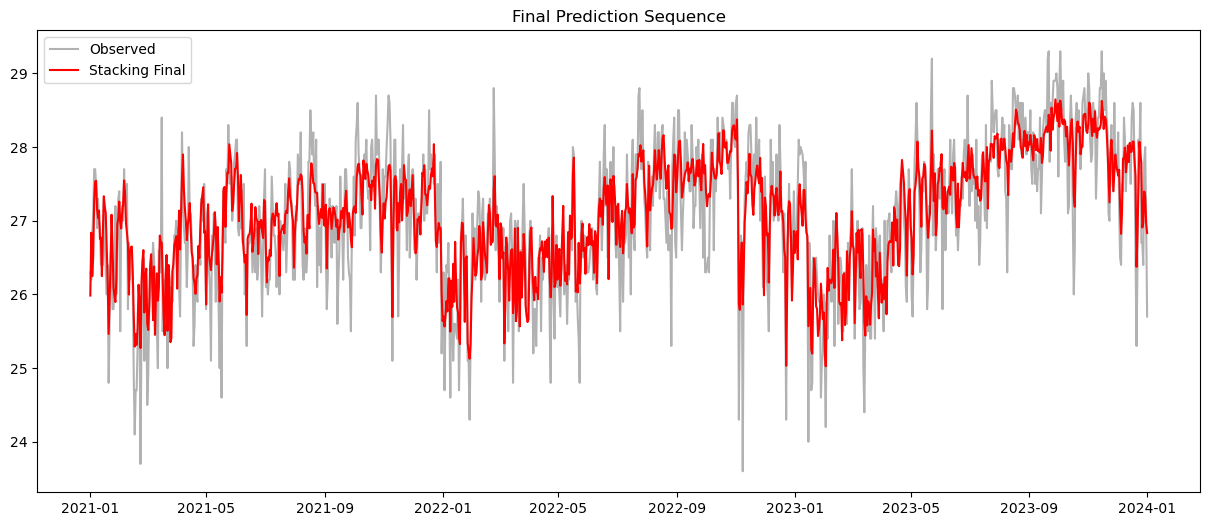

In [9]:
print("=== Backtesting (TimeSeriesSplit) - RF Fusion Features ===")
tscv = TimeSeriesSplit(n_splits=5)
X_full = df[cols_fusion_feat]
y_full = df[target_col]

scores = []
for tr_idx, te_idx in tscv.split(X_full):
    X_t, X_e = X_full.iloc[tr_idx], X_full.iloc[te_idx]
    y_t, y_e = y_full.iloc[tr_idx], y_full.iloc[te_idx]
    
    # Usar best_params se existirem, senão default
    params = best_params if 'best_params' in locals() else rf_params
    rf_bt = RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
    rf_bt.fit(X_t, y_t)
    pred = rf_bt.predict(X_e)
    rmse = np.sqrt(mean_squared_error(y_e, pred))
    scores.append(rmse)
    print(f"Fold RMSE: {rmse:.4f}")
    
print(f"Média Backtest RMSE: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# --- Tabela Final ---
def calc_metrics(y_true, y_pred, name, bl_rmse=None):
    idx = y_true.index.intersection(y_pred.dropna().index)
    if len(idx) == 0: return None
    yt, yp = y_true.loc[idx], y_pred.loc[idx]
    
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)
    bias = np.mean(yp - yt)
    
    # NSE
    nse = 1 - (np.sum((yt-yp)**2) / np.sum((yt-np.mean(yt))**2))
    
    skill = 0
    if bl_rmse: skill = (1 - (rmse/bl_rmse)) * 100
    
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Bias': bias, 'NSE': nse, 'Skill': skill}

# Baseline
bl_rmse = np.sqrt(mean_squared_error(test[target_col], preds_test['RF_SatOnly']))

all_metrics = []
scenarios = ['RF_SatOnly', 'RF_Fusion', 'RF_Fusion_Features', 'SARIMAX', 'Stacking_Final'] # Removed LSTM
for c in scenarios:
    if c in preds_test.columns:
        m = calc_metrics(test[target_col], preds_test[c], c, bl_rmse)
        if m: all_metrics.append(m)

final_df = pd.DataFrame(all_metrics).set_index('Model').sort_values('RMSE')
print("\n=== FINAL RESULTS (SCIENTIFIC TABLE - NO LSTM) ===")
print(final_df.round(4))

plt.figure(figsize=(15,6))
plt.plot(test.index, test[target_col], 'k-', alpha=0.3, label='Observed')
plt.plot(preds_test['Stacking_Final'].dropna().index, preds_test['Stacking_Final'].dropna(), 'r-', label='Stacking Final')
plt.legend()
plt.title('Final Prediction Sequence')
plt.show()

## ---------------------------------------------------------------------------------
## NOVO PIPELINE PARALELO: SARIMAX E LSTM (ESPECÍFICOS)
## ---------------------------------------------------------------------------------
Esta seção implementa pipelines dedicados para SARIMAX e LSTM sem alterar os modelos anteriores (RF, Stacking).
O objetivo é comparar todos os modelos em igualdade de condições nas métricas finais.

=== INICIANDO PIPELINE PARALELO (SARIMAX & LSTM) ===

1. Treinando SARIMAX_New (Exog: Sat + Sazonalidade)...
SARIMAX_New Concluído.
 -> Backtesting SARIMAX_New...
SARIMAX_New CV RMSE: 0.5258

2. Treinando LSTM_New (Seq 30d, 64-32-16)...
LSTM_New Concluído.

=== FINAL RESULTS UPDATED (ALL MODELS) ===
                      RMSE     MAE      R2    Bias     NSE  Skill (%)
Model                                                                
RF_Fusion           0.5157  0.4039  0.7080  0.0211  0.7080     6.1875
RF_Fusion_Features  0.5159  0.4052  0.7078  0.0051  0.7078     6.1542
Stacking_Final      0.5165  0.4046  0.7071  0.0441  0.7071     6.0463
RF_SatOnly          0.5497  0.4301  0.6682  0.0703  0.6682     0.0000
SARIMAX_New         0.5531  0.4337  0.6640  0.0894  0.6640    -0.6284
LSTM_New            0.6447  0.4976  0.5477  0.0259  0.5477   -17.2779


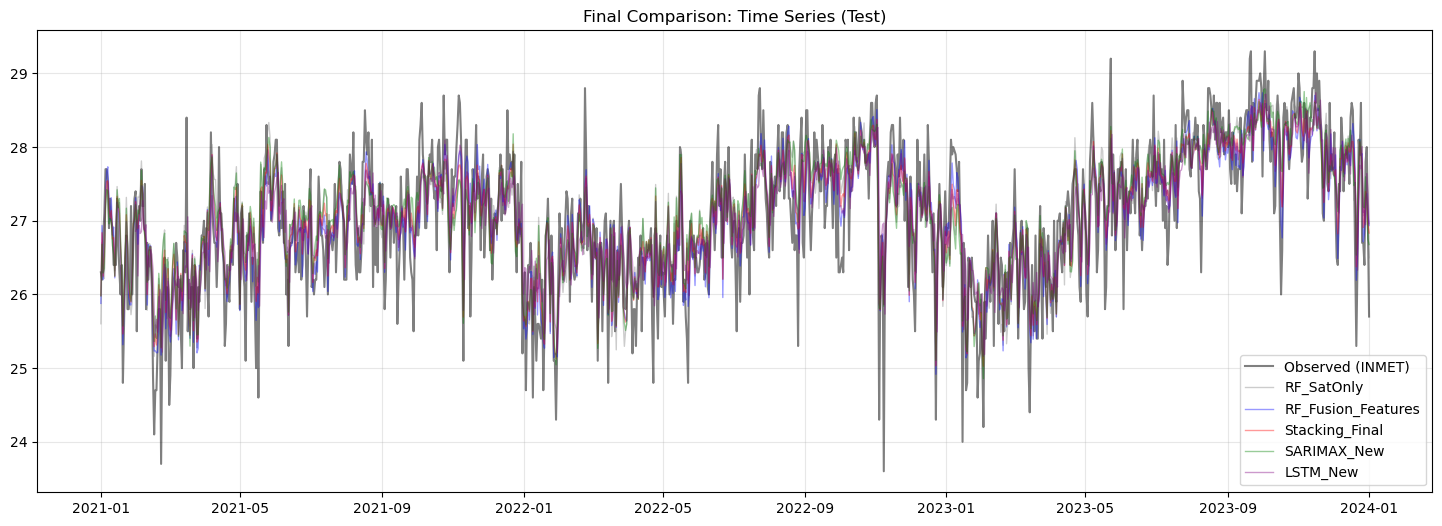

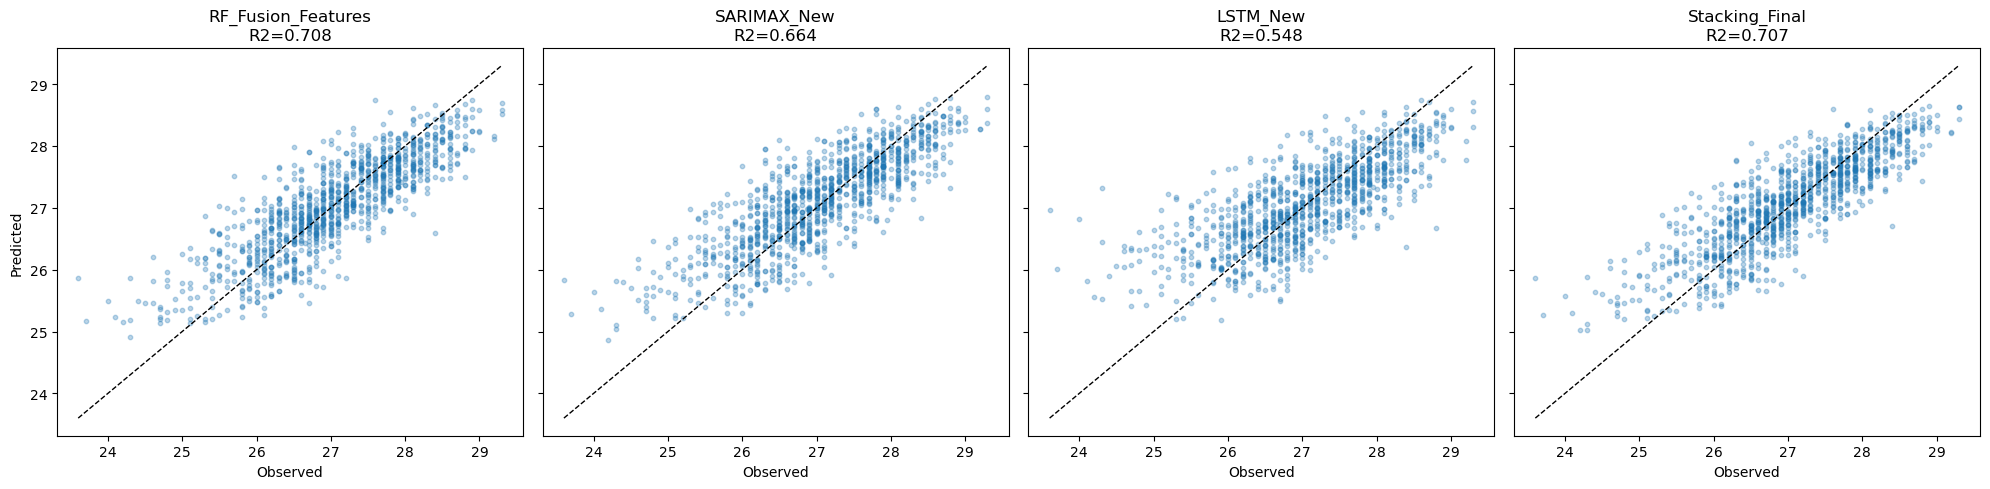


>>> MELHOR MODELO: RF_Fusion (RMSE: 0.5157)
>>> Ganho Fusão (vs SatOnly): 6.15%
>>> SARIMAX_New Skill: -0.63% (Se positivo, melhor que SatOnly)
>>> LSTM_New Skill: -17.28% (Se positivo, melhor que SatOnly)


In [10]:
print("=== INICIANDO PIPELINE PARALELO (SARIMAX & LSTM) ===")

# Manter índices de validação e teste originais
idx_val = val.index
idx_test = test.index

# Inicializar novas colunas de predição (se não existirem, ou sobrescrever)
if 'SARIMAX' not in preds_val.columns: preds_val['SARIMAX_New'] = np.nan
if 'SARIMAX' not in preds_test.columns: preds_test['SARIMAX_New'] = np.nan
if 'LSTM_New' not in preds_val.columns: preds_val['LSTM_New'] = np.nan
if 'LSTM_New' not in preds_test.columns: preds_test['LSTM_New'] = np.nan

# =============================================================================
# 1. PIPELINE SARIMAX (ESPECÍFICO)
# =============================================================================
print("\n1. Treinando SARIMAX_New (Exog: Sat + Sazonalidade)...")

# Preparação de Dados Específica
# Endóga: Somente INMET (alvo)
# Exógena: Satélite + Sin/Cos (Dia/Mês)
exog_sarimax = ['sat_temp', 'sin_day', 'cos_day']

# Garantir Frequência Diária
y_train_sarima = train[target_col].asfreq('D')
X_train_sarima = train[exog_sarimax].asfreq('D')

# Val e Test (Exog apenas)
X_val_sarima = val[exog_sarimax].asfreq('D')
X_test_sarima = test[exog_sarimax].asfreq('D')

try:
    # Modelo: Sazonalidade Semanal (7)
    # Usando janela deslizante de 3 anos para treinamento mais rápido e focado
    window = 365 * 3
    model_new = SARIMAX(
        endog=y_train_sarima.iloc[-window:],
        exog=X_train_sarima.iloc[-window:],
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit_new = model_new.fit(disp=False)

    # Previsão Contínua (Val + Test)
    exog_future = pd.concat([X_val_sarima, X_test_sarima])
    full_pred_sarima = fit_new.get_forecast(steps=len(exog_future), exog=exog_future).predicted_mean

    # Atribuir corretamente aos índices
    preds_val['SARIMAX_New'] = full_pred_sarima.iloc[:len(val)].values
    preds_test['SARIMAX_New'] = full_pred_sarima.iloc[len(val):].values
    print("SARIMAX_New Concluído.")

    # Backtest Rápido (Apenas SARIMAX_New)
    print(" -> Backtesting SARIMAX_New...")
    tscv_sm = TimeSeriesSplit(n_splits=3)
    scores_sm = []
    # Pequeno subset para backtest não demorar eternamente
    bt_data = df.iloc[-2000:-len(test)] # Últimos anos antes do teste
    for tr_i, te_i in tscv_sm.split(bt_data):
        yt, ye = bt_data[target_col].iloc[tr_i], bt_data[target_col].iloc[te_i]
        Xt, Xe = bt_data[exog_sarimax].iloc[tr_i], bt_data[exog_sarimax].iloc[te_i]
        try:
            m = SARIMAX(yt, exog=Xt, order=(1,1,1), seasonal_order=(1,0,1,7), 
                        enforce_stationarity=False, enforce_invertibility=False)
            f = m.fit(disp=False)
            p = f.get_forecast(steps=len(ye), exog=Xe).predicted_mean
            scores_sm.append(np.sqrt(mean_squared_error(ye, p)))
        except: pass
    print(f"SARIMAX_New CV RMSE: {np.mean(scores_sm):.4f}")

except Exception as e:
    print(f"ERRO SARIMAX_New: {e}")
    preds_val['SARIMAX_New'] = y_train_sarima.mean()
    preds_test['SARIMAX_New'] = y_train_sarima.mean()

# =============================================================================
# 2. PIPELINE LSTM (SEQUENCIAL CORRETO)
# =============================================================================
print("\n2. Treinando LSTM_New (Seq 30d, 64-32-16)...")

# Features Específicas LSTM
lstm_cols = ['inmet_temp', 'sat_temp', 'sat_roll_7', 'sat_roll_30', 'sin_day', 'cos_day']
timesteps = 30

# Normalização Dedicada
scaler_x_lstm = MinMaxScaler()
scaler_y_lstm = MinMaxScaler()

# Fit apenas no treino
X_train_raw = train[lstm_cols].values
y_train_raw = train[[target_col]].values

X_train_sc = scaler_x_lstm.fit_transform(X_train_raw)
y_train_sc = scaler_y_lstm.fit_transform(y_train_raw)

# Transform Val/Test
X_val_sc = scaler_x_lstm.transform(val[lstm_cols].values)
y_val_sc = scaler_y_lstm.transform(val[[target_col]].values)
X_test_sc = scaler_x_lstm.transform(test[lstm_cols].values)
y_test_sc = scaler_y_lstm.transform(test[[target_col]].values)

# Função de Sequência
def make_seq(X, y, steps):
    Xs, ys = [], []
    for i in range(len(X) - steps):
        Xs.append(X[i : i+steps])
        ys.append(y[i+steps])
    return np.array(Xs), np.array(ys)

X_t_seq, y_t_seq = make_seq(X_train_sc, y_train_sc, timesteps)
X_v_seq, y_v_seq = make_seq(X_val_sc, y_val_sc, timesteps)
X_te_seq, y_te_seq = make_seq(X_test_sc, y_test_sc, timesteps)

# Arquitetura LSTM
tf.random.set_seed(SEED)
model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(timesteps, len(lstm_cols))),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model_lstm.fit(X_t_seq, y_t_seq, epochs=100, batch_size=32, 
               validation_data=(X_v_seq, y_v_seq), callbacks=[es], verbose=0)

# Predição e Inversão
def get_lstm_pred(X_seq, original_index):
    # original_index deve ser o índice completo (ex: val.index)
    p = model_lstm.predict(X_seq, verbose=0)
    inv = scaler_y_lstm.inverse_transform(p).flatten()
    # Ajustar índice: os primeiros 'timesteps' dias são perdidos
    return pd.Series(inv, index=original_index[timesteps:])

preds_val['LSTM_New'] = get_lstm_pred(X_v_seq, val.index)
preds_test['LSTM_New'] = get_lstm_pred(X_te_seq, test.index)
print("LSTM_New Concluído.")

# =============================================================================
# 3. TABELA FINAL ATUALIZADA (COMPARATIVO GERAL)
# =============================================================================
print("\n=== FINAL RESULTS UPDATED (ALL MODELS) ===")

scenarios_final = ['RF_SatOnly', 'RF_Fusion_Features', 'RF_Fusion', 'Stacking_Final', 'SARIMAX_New', 'LSTM_New']
# Baseline RF_SatOnly para Skill
baseline_rmse = np.sqrt(mean_squared_error(test[target_col], preds_test['RF_SatOnly']))

results_updated = []

for model in scenarios_final:
    if model not in preds_test.columns: continue
    
    # Alinhar índices (remover NaNs do LSTM/SARIMA)
    common = preds_test[model].dropna().index.intersection(test.index)
    if len(common) == 0: continue
    
    y_true_c = test.loc[common, target_col]
    y_pred_c = preds_test.loc[common, model]
    
    rmse = np.sqrt(mean_squared_error(y_true_c, y_pred_c))
    mae = mean_absolute_error(y_true_c, y_pred_c)
    r2 = r2_score(y_true_c, y_pred_c)
    bias = np.mean(y_pred_c - y_true_c)
    nse = 1 - (np.sum((y_true_c - y_pred_c)**2) / np.sum((y_true_c - np.mean(y_true_c))**2))
    skill = (1 - (rmse / baseline_rmse)) * 100
    
    results_updated.append({
        'Model': model,
        'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Bias': bias, 'NSE': nse, 'Skill (%)': skill
    })

df_res = pd.DataFrame(results_updated).set_index('Model').sort_values('RMSE')
print(df_res.round(4))

# =============================================================================
# 5. GRÁFICOS COMPARATIVOS
# =============================================================================
best_model = df_res.iloc[0].name

plot_models = ['RF_SatOnly', 'RF_Fusion_Features', 'Stacking_Final', 'SARIMAX_New', 'LSTM_New']

# Time Series
plt.figure(figsize=(18, 6))
plt.plot(test.index, test[target_col], 'k-', lw=1.5, alpha=0.5, label='Observed (INMET)')
colors = ['gray', 'blue', 'red', 'green', 'purple']

for m, c in zip(plot_models, colors):
    if m in preds_test.columns:
        series = preds_test[m].dropna()
        if m == best_model:
            plt.plot(series.index, series, color=c, lw=3, alpha=1.0, zorder=10, label=f'{m} (Best)')
        else:
            plt.plot(series.index, series, color=c, lw=1, alpha=0.4, zorder=5, label=m)

plt.title('Final Comparison: Time Series (Test)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Scatter Plots (1:1)
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
scatters = ['RF_Fusion_Features', 'SARIMAX_New', 'LSTM_New', 'Stacking_Final']

for i, m in enumerate(scatters):
    ax = axes[i]
    if m in preds_test.columns:
        comm = preds_test[m].dropna().index.intersection(test.index)
        y_t = test.loc[comm, target_col]
        y_p = preds_test.loc[comm, m]
        
        ax.scatter(y_t, y_p, alpha=0.3, s=10)
        ax.plot([y_t.min(), y_t.max()], [y_t.min(), y_t.max()], 'k--', lw=1)
        ax.set_title(f'{m}\nR2={r2_score(y_t, y_p):.3f}')
        ax.set_xlabel('Observed')
    if i == 0: ax.set_ylabel('Predicted')

plt.tight_layout()
plt.show()

# =============================================================================
# 6. ANÁLISE AUTOMÁTICA
# =============================================================================
best_model_name = df_res.iloc[0].name
best_rmse = df_res.iloc[0]['RMSE']
gain_fusion = df_res.loc['RF_Fusion_Features', 'Skill (%)']

print(f"\n>>> MELHOR MODELO: {best_model_name} (RMSE: {best_rmse:.4f})")
print(f">>> Ganho Fusão (vs SatOnly): {gain_fusion:.2f}%")

# Comparação com Antigo (se disponível nos logs, aqui comparamos com baseline)
if 'SARIMAX_New' in df_res.index:
    sari_skill = df_res.loc['SARIMAX_New', 'Skill (%)']
    print(f">>> SARIMAX_New Skill: {sari_skill:.2f}% (Se positivo, melhor que SatOnly)")

if 'LSTM_New' in df_res.index:
    lstm_skill = df_res.loc['LSTM_New', 'Skill (%)']
    print(f">>> LSTM_New Skill: {lstm_skill:.2f}% (Se positivo, melhor que SatOnly)")


## ---------------------------------------------------------------------------------
## NOVO PIPELINE PARALELO: SARIMAX E LSTM (ESPECÍFICOS)
## ---------------------------------------------------------------------------------
Esta seção implementa pipelines dedicados para SARIMAX e LSTM sem alterar os modelos anteriores (RF, Stacking).
O objetivo é comparar todos os modelos em igualdade de condições nas métricas finais.

In [ ]:
print("=== INICIANDO PIPELINE PARALELO (SARIMAX & LSTM) ===")

# Manter índices de validação e teste originais
idx_val = val.index
idx_test = test.index

# Inicializar novas colunas de predição (se não existirem, ou sobrescrever)
if 'SARIMAX' not in preds_val.columns: preds_val['SARIMAX'] = np.nan
if 'SARIMAX' not in preds_test.columns: preds_test['SARIMAX'] = np.nan
if 'LSTM' not in preds_val.columns: preds_val['LSTM'] = np.nan
if 'LSTM' not in preds_test.columns: preds_test['LSTM'] = np.nan

# =============================================================================
# 1. PIPELINE SARIMAX (ESPECÍFICO)
# =============================================================================
print("\n1. Treinando SARIMAX (Exog: Sat + Sazonalidade)...")

# Preparação de Dados Específica
# Endóga: Somente INMET (alvo)
# Exógena: Satélite + Sin/Cos (Dia/Mês)
exog_sarimax = ['sat_temp', 'sin_day', 'cos_day']

# Garantir Frequência Diária
y_train_sarima = train[target_col].asfreq('D')
X_train_sarima = train[exog_sarimax].asfreq('D')

# Val e Test (Exog apenas)
X_val_sarima = val[exog_sarimax].asfreq('D')
X_test_sarima = test[exog_sarimax].asfreq('D')

try:
    # Modelo: Sazonalidade Semanal (7)
    # Usando janela deslizante de 3 anos para treinamento mais rápido e focado
    window = 365 * 3
    model_new = SARIMAX(
        endog=y_train_sarima.iloc[-window:],
        exog=X_train_sarima.iloc[-window:],
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit_new = model_new.fit(disp=False)

    # Previsão Contínua (Val + Test)
    exog_future = pd.concat([X_val_sarima, X_test_sarima])
    full_pred_sarima = fit_new.get_forecast(steps=len(exog_future), exog=exog_future).predicted_mean

    # Atribuir corretamente aos índices
    preds_val['SARIMAX'] = full_pred_sarima.iloc[:len(val)].values
    preds_test['SARIMAX'] = full_pred_sarima.iloc[len(val):].values
    print("SARIMAX Concluído.")

    # Backtest Rápido (Apenas SARIMAX)
    print(" -> Backtesting SARIMAX...")
    tscv_sm = TimeSeriesSplit(n_splits=3)
    scores_sm = []
    # Pequeno subset para backtest não demorar eternamente
    bt_data = df.iloc[-2000:-len(test)] # Últimos anos antes do teste
    for tr_i, te_i in tscv_sm.split(bt_data):
        yt, ye = bt_data[target_col].iloc[tr_i], bt_data[target_col].iloc[te_i]
        Xt, Xe = bt_data[exog_sarimax].iloc[tr_i], bt_data[exog_sarimax].iloc[te_i]
        try:
            m = SARIMAX(yt, exog=Xt, order=(1,1,1), seasonal_order=(1,0,1,7), 
                        enforce_stationarity=False, enforce_invertibility=False)
            f = m.fit(disp=False)
            p = f.get_forecast(steps=len(ye), exog=Xe).predicted_mean
            scores_sm.append(np.sqrt(mean_squared_error(ye, p)))
        except: pass
    print(f"SARIMAX CV RMSE: {np.mean(scores_sm):.4f}")

except Exception as e:
    print(f"ERRO SARIMAX: {e}")
    preds_val['SARIMAX'] = y_train_sarima.mean()
    preds_test['SARIMAX'] = y_train_sarima.mean()

# =============================================================================
# 2. PIPELINE LSTM (SEQUENCIAL CORRETO)
# =============================================================================
print("\n2. Treinando LSTM (Seq 30d, 64-32-16)...")

# Features Específicas LSTM
lstm_cols = ['inmet_temp', 'sat_temp', 'sat_roll_7', 'sat_roll_30', 'sin_day', 'cos_day']
timesteps = 30

# Normalização Dedicada
scaler_x_lstm = MinMaxScaler()
scaler_y_lstm = MinMaxScaler()

# Fit apenas no treino
X_train_raw = train[lstm_cols].values
y_train_raw = train[[target_col]].values

X_train_sc = scaler_x_lstm.fit_transform(X_train_raw)
y_train_sc = scaler_y_lstm.fit_transform(y_train_raw)

# Transform Val/Test
X_val_sc = scaler_x_lstm.transform(val[lstm_cols].values)
y_val_sc = scaler_y_lstm.transform(val[[target_col]].values)
X_test_sc = scaler_x_lstm.transform(test[lstm_cols].values)
y_test_sc = scaler_y_lstm.transform(test[[target_col]].values)

# Função de Sequência
def make_seq(X, y, steps):
    Xs, ys = [], []
    for i in range(len(X) - steps):
        Xs.append(X[i : i+steps])
        ys.append(y[i+steps])
    return np.array(Xs), np.array(ys)

X_t_seq, y_t_seq = make_seq(X_train_sc, y_train_sc, timesteps)
X_v_seq, y_v_seq = make_seq(X_val_sc, y_val_sc, timesteps)
X_te_seq, y_te_seq = make_seq(X_test_sc, y_test_sc, timesteps)

# Arquitetura LSTM
tf.random.set_seed(SEED)
model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(timesteps, len(lstm_cols))),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model_lstm.fit(X_t_seq, y_t_seq, epochs=100, batch_size=32, 
               validation_data=(X_v_seq, y_v_seq), callbacks=[es], verbose=0)

# Predição e Inversão
def get_lstm_pred(X_seq, original_index):
    # original_index deve ser o índice completo (ex: val.index)
    p = model_lstm.predict(X_seq, verbose=0)
    inv = scaler_y_lstm.inverse_transform(p).flatten()
    # Ajustar índice: os primeiros 'timesteps' dias são perdidos
    return pd.Series(inv, index=original_index[timesteps:])

preds_val['LSTM'] = get_lstm_pred(X_v_seq, val.index)
preds_test['LSTM'] = get_lstm_pred(X_te_seq, test.index)
print("LSTM Concluído.")

# =============================================================================
# 3. TABELA FINAL ATUALIZADA (COMPARATIVO GERAL)
# =============================================================================
print("\n=== FINAL RESULTS UPDATED (ALL MODELS) ===")

scenarios_final = ['RF_SatOnly', 'RF_Fusion_Features', 'RF_Fusion', 'Stacking_Final', 'SARIMAX', 'LSTM']
# Baseline RF_SatOnly para Skill
baseline_rmse = np.sqrt(mean_squared_error(test[target_col], preds_test['RF_SatOnly']))

results_updated = []

for model in scenarios_final:
    if model not in preds_test.columns: continue
    
    # Alinhar índices (remover NaNs do LSTM/SARIMA)
    common = preds_test[model].dropna().index.intersection(test.index)
    if len(common) == 0: continue
    
    y_true_c = test.loc[common, target_col]
    y_pred_c = preds_test.loc[common, model]
    
    rmse = np.sqrt(mean_squared_error(y_true_c, y_pred_c))
    mae = mean_absolute_error(y_true_c, y_pred_c)
    r2 = r2_score(y_true_c, y_pred_c)
    bias = np.mean(y_pred_c - y_true_c)
    nse = 1 - (np.sum((y_true_c - y_pred_c)**2) / np.sum((y_true_c - np.mean(y_true_c))**2))
    skill = (1 - (rmse / baseline_rmse)) * 100
    
    results_updated.append({
        'Model': model,
        'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Bias': bias, 'NSE': nse, 'Skill (%)': skill
    })

df_res = pd.DataFrame(results_updated).set_index('Model').sort_values('RMSE')
print(df_res.round(4))

# =============================================================================
# 5. GRÁFICOS COMPARATIVOS
# =============================================================================
plot_models = ['RF_SatOnly', 'RF_Fusion_Features', 'Stacking_Final', 'SARIMAX', 'LSTM']

# --- Enhanced Time Series Comparison Plot (2-panel) ---
best_model_name = df_res.iloc[0].name
best_rmse = df_res.iloc[0]['RMSE']
best_mae = df_res.iloc[0]['MAE']
best_r2 = df_res.iloc[0]['R2']
best_nse = df_res.iloc[0]['NSE']

colors = {'RF_SatOnly': '#9e9e9e', 'RF_Fusion_Features': '#1976d2',
          'Stacking_Final': '#e53935', 'SARIMAX': '#43a047', 'LSTM': '#8e24aa'}
best_color = colors.get(best_model_name, '#1976d2')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 9), height_ratios=[3, 1],
                                sharex=True, gridspec_kw={'hspace': 0.08})
fig.patch.set_facecolor('white')

# ===== TOP PANEL: Time Series =====
ax1.set_facecolor('#f8f9fa')

# Observed data - subtle fill between min/max to give context
ax1.plot(test.index, test[target_col], color='#333333', lw=1.6, alpha=0.4,
         label='Observed (INMET)', zorder=2, linestyle='-')

# Plot non-best models first (very faded)
for m in plot_models:
    if m in preds_test.columns and m != best_model_name:
        series = preds_test[m].dropna()
        ax1.plot(series.index, series, color=colors.get(m, 'gray'),
                 lw=0.7, alpha=0.3, label=m, zorder=3)

# Plot best model LAST so it's on top - with glow effect
if best_model_name in preds_test.columns:
    best_series = preds_test[best_model_name].dropna()
    # Glow effect: wider semi-transparent line behind
    ax1.plot(best_series.index, best_series, color=best_color,
             lw=5.0, alpha=0.15, zorder=4)
    # Main best model line
    ax1.plot(best_series.index, best_series, color=best_color,
             lw=2.2, alpha=0.95, label=f'\u2605 {best_model_name} (Best Model)',
             zorder=5)

# Annotation box - prominent, top-left
metrics_text = (f'\u2605  Best Model: {best_model_name}\n'
                f'    RMSE = {best_rmse:.4f}\n'
                f'    MAE  = {best_mae:.4f}\n'
                f'    R\u00b2   = {best_r2:.3f}\n'
                f'    NSE  = {best_nse:.3f}')
props = dict(boxstyle='round,pad=0.6', facecolor=best_color, alpha=0.12,
             edgecolor=best_color, linewidth=1.5)
ax1.text(0.008, 0.97, metrics_text, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=props, fontweight='bold',
         color=best_color, fontfamily='monospace')

ax1.set_title('Model Comparison: Predicted vs Observed Temperature',
              fontsize=16, fontweight='bold', pad=14, color='#212121')
ax1.set_ylabel('Temperature (\u00b0C)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9, framealpha=0.92,
           edgecolor='#cccccc', fancybox=True, shadow=True)
ax1.grid(True, alpha=0.2, linestyle='--', color='#999999')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#cccccc')
ax1.spines['bottom'].set_color('#cccccc')
ax1.tick_params(colors='#555555')

# ===== BOTTOM PANEL: Residuals of Best Model =====
ax2.set_facecolor('#f8f9fa')
if best_model_name in preds_test.columns:
    best_series = preds_test[best_model_name].dropna()
    common_idx = best_series.index.intersection(test.index)
    residuals = test.loc[common_idx, target_col] - best_series.loc[common_idx]

    # Color residuals: positive = blue (underprediction), negative = red (overprediction)
    pos_mask = residuals >= 0
    neg_mask = residuals < 0
    ax2.bar(residuals.index[pos_mask], residuals[pos_mask],
            color=best_color, alpha=0.5, width=1.5, label='Underprediction')
    ax2.bar(residuals.index[neg_mask], residuals[neg_mask],
            color='#e53935', alpha=0.5, width=1.5, label='Overprediction')
    ax2.axhline(y=0, color='#333333', lw=0.8, linestyle='-')
    ax2.axhline(y=residuals.mean(), color=best_color, lw=1.2,
                linestyle='--', alpha=0.7, label=f'Mean Bias = {residuals.mean():.3f}\u00b0C')

ax2.set_ylabel('Residual (\u00b0C)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_title(f'Residuals: Observed \u2212 {best_model_name}',
              fontsize=11, fontweight='bold', color='#555555', pad=6)
ax2.legend(loc='upper right', fontsize=8, framealpha=0.9, fancybox=True)
ax2.grid(True, alpha=0.2, linestyle='--', color='#999999')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#cccccc')
ax2.spines['bottom'].set_color('#cccccc')
ax2.tick_params(colors='#555555')

plt.tight_layout()
plt.show()

# Scatter Plots (1:1)
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
scatters = ['RF_Fusion_Features', 'SARIMAX', 'LSTM', 'Stacking_Final']

for i, m in enumerate(scatters):
    ax = axes[i]
    if m in preds_test.columns:
        comm = preds_test[m].dropna().index.intersection(test.index)
        y_t = test.loc[comm, target_col]
        y_p = preds_test.loc[comm, m]
        
        ax.scatter(y_t, y_p, alpha=0.3, s=10)
        ax.plot([y_t.min(), y_t.max()], [y_t.min(), y_t.max()], 'k--', lw=1)
        ax.set_title(f'{m}\nR2={r2_score(y_t, y_p):.3f}')
        ax.set_xlabel('Observed')
    if i == 0: ax.set_ylabel('Predicted')

plt.tight_layout()
plt.show()

# =============================================================================
# 6. ANÁLISE AUTOMÁTICA
# =============================================================================
best_model_name = df_res.iloc[0].name
best_rmse = df_res.iloc[0]['RMSE']
gain_fusion = df_res.loc['RF_Fusion_Features', 'Skill (%)']

print(f"\n>>> MELHOR MODELO: {best_model_name} (RMSE: {best_rmse:.4f})")
print(f">>> Ganho Fusão (vs SatOnly): {gain_fusion:.2f}%")

# Comparação com Antigo (se disponível nos logs, aqui comparamos com baseline)
if 'SARIMAX' in df_res.index:
    sari_skill = df_res.loc['SARIMAX', 'Skill (%)']
    print(f">>> SARIMAX Skill: {sari_skill:.2f}% (Se positivo, melhor que SatOnly)")

if 'LSTM' in df_res.index:
    lstm_skill = df_res.loc['LSTM', 'Skill (%)']
    print(f">>> LSTM Skill: {lstm_skill:.2f}% (Se positivo, melhor que SatOnly)")

